#### **Problem Statement:**

1.  The main aim of the problem statement is to determine whether the student has passed or failed based on the following parameters :---

    (a.)  Study Hours

    (b.)  Attendance Percentage

    (c.)  Previous Exam Scores

####  **Steps used in this Algorithm:-**

1.  Import the required libraries

2.  Create Sample Dataset

3.  Perform the Data Exploration

4.  Data Cleaning and Preprocessing

5.  Divide the dataset into independent and dependent features

6.  Divide the independent and dependent features into training and testing data

7.  Perform the Feature Scaling

8.  Build the ANN Model

9.  Compile the ANN Model

10. Train the ANN Model

11. Make the Prediction for the model

12. Evaluate Model Performance

13. Actual vs Predicted Comparison

14. Predict the output or the sample data whether the student is pass or fail

#### **Step 1: Import the required libraries**

In [698]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   sklearn.model_selection import train_test_split
from   sklearn.preprocessing   import StandardScaler
from   sklearn.metrics         import accuracy_score, confusion_matrix, classification_report

from   tensorflow.keras.models import Sequential
from   tensorflow.keras.layers import Dense

#### **OBSERVATIONS:**

1.  Sequential -------->  A linear model is created stack by stack

2.  Dense      -------->  It forms a dense layers of neural networks.

#### **Step 2: Create Sample Dataset**

In [699]:
#### Create the sample dataset

data = {
    "Study_Hours": [
        1,2,3,4,5,6,7,8,9,10,11,12,
        2,3,4,5,6,7,8,9,10,11,12,13,
        1,2,3,4,5,6,7,8,9,10,11,12,
        4,5,6,7,8,9,10,11,12,13,14,15,
        3,4,5,6,7,8,9,10,11,12,13,14
    ],

    "Attendance": [
        50,55,60,65,70,75,80,85,90,95,96,98,
        52,58,62,68,72,78,82,88,92,94,97,99,
        48,54,59,64,69,74,79,84,89,93,95,97,
        63,67,72,77,81,86,89,92,95,97,98,99,
        57,61,66,71,76,80,84,87,91,94,96,98
    ],

    "Previous_Score": [
        30,35,40,45,50,55,60,65,70,80,85,90,
        32,38,42,48,53,58,63,68,73,82,87,92,
        28,33,39,44,49,54,59,64,69,78,83,88,
        46,51,56,61,66,71,76,81,86,89,92,95,
        37,43,47,52,57,62,67,72,77,84,88,93
    ],

    "Result": [
        0,0,0,0,0,1,1,1,1,1,1,1,
        0,0,0,0,1,1,1,1,1,1,1,1,
        0,0,0,0,0,1,1,1,1,1,1,1,
        0,0,1,1,1,1,1,1,1,1,1,1,
        0,0,0,1,1,1,1,1,1,1,1,1
    ]
}


#### Create the dataframe from the data
df = pd.DataFrame(data)
print(df)

    Study_Hours  Attendance  Previous_Score  Result
0             1          50              30       0
1             2          55              35       0
2             3          60              40       0
3             4          65              45       0
4             5          70              50       0
5             6          75              55       1
6             7          80              60       1
7             8          85              65       1
8             9          90              70       1
9            10          95              80       1
10           11          96              85       1
11           12          98              90       1
12            2          52              32       0
13            3          58              38       0
14            4          62              42       0
15            5          68              48       0
16            6          72              53       1
17            7          78              58       1
18          

#### **OBSERVATIONS:**

1.  The dataset explains about the student mark details such as:----

    (a.)  Study_Hours  -------->  Study hours for each student.

    (b.)  Attendance   -------->  Attendance score for each student.

    (c.)  Previous_Score ------->  Previous score of each student.

    (d.)  Result  -------------->  It tells whether the student has passed or failed.

#### **Step 3: Perform the Data Exploration**

In [700]:
#### Length of the dataset
print("Length of the dataset is:", len(df))

Length of the dataset is: 60


In [701]:
#### Shape of the dataset
print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (60, 4)


In [702]:
#### get the columns used in the dataset
print("Column used in the dataset is:", df.columns)

Column used in the dataset is: Index(['Study_Hours', 'Attendance', 'Previous_Score', 'Result'], dtype='object')


In [703]:
#### get the information about the columns used in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     60 non-null     int64
 1   Attendance      60 non-null     int64
 2   Previous_Score  60 non-null     int64
 3   Result          60 non-null     int64
dtypes: int64(4)
memory usage: 2.0 KB


#### **OBSERVATIONS:**

1.  The above dataframe provides us the information about the columns used in the dataset.

In [704]:
#### get the statistical information about the columns used in the dataset
df.describe()

,Study_Hours,Attendance,Previous_Score,Result
count,60.000000,60.000000,60.000000,60.000000
mean,7.700000,79.050000,62.966667,0.683333
std,3.674465,15.118094,19.007551,0.469102
min,1.000000,48.000000,28.000000,0.000000
25%,5.000000,66.750000,47.750000,0.000000
50%,8.000000,80.500000,62.500000,1.000000
75%,11.000000,93.250000,80.250000,1.000000
max,15.000000,99.000000,95.000000,1.000000


#### **OBSERVATIONS:**

1.  It explains the statistical information about each column used in the dataset.

#### **Step 4: Data Cleaning and Preprocessing**

In [705]:
#### check if there are any NULL records in the dataset
df.isnull().sum()

,0
Study_Hours,0
Attendance,0
Previous_Score,0
Result,0


#### **OBSERVATIONS:**

1.  There are no NULL records in the dataset.

In [706]:
#### Check for any duplicate records in the dataset

df[df.duplicated()]

,Study_Hours,Attendance,Previous_Score,Result


#### **OBSERVATIONS:**

1.  There are no duplicate records in the dataset.

#### **Step 5: Divide the dataset into independent and dependent features**

In [707]:
#### Divide the dataset into independent and dependent features

X = df.drop(columns='Result',axis=1)
print(X)

    Study_Hours  Attendance  Previous_Score
0             1          50              30
1             2          55              35
2             3          60              40
3             4          65              45
4             5          70              50
5             6          75              55
6             7          80              60
7             8          85              65
8             9          90              70
9            10          95              80
10           11          96              85
11           12          98              90
12            2          52              32
13            3          58              38
14            4          62              42
15            5          68              48
16            6          72              53
17            7          78              58
18            8          82              63
19            9          88              68
20           10          92              73
21           11          94     

#### **OBSERVATIONS:**

1.  The above dataset contains the input feature details:---

    (a.) Study_Hours ------->  Total hours studied by the student.

    (b.) Attendance -------->  Attendance score secured by the student.

    (c.) Previous_Score -----> Previous score secures by the student.

In [708]:
Y = df['Result']
print(Y)

0     0
1     0
2     0
3     0
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    0
13    0
14    0
15    0
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    0
25    0
26    0
27    0
28    0
29    1
30    1
31    1
32    1
33    1
34    1
35    1
36    0
37    0
38    1
39    1
40    1
41    1
42    1
43    1
44    1
45    1
46    1
47    1
48    0
49    0
50    0
51    1
52    1
53    1
54    1
55    1
56    1
57    1
58    1
59    1
Name: Result, dtype: int64


#### **OBSERVATIONS:**

1.  The above dataset contains the output feature as 'Result'.

#### **Step 6: Divide the independent and dependent features into training and testing data**

In [709]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [710]:
X_train

,Study_Hours,Attendance,Previous_Score
38,6,72,56
7,8,85,65
15,5,68,48
29,6,74,54
32,9,89,69
26,3,59,39
18,8,82,63
24,1,48,28
2,3,60,40
46,14,98,92


In [711]:
X_test

,Study_Hours,Attendance,Previous_Score
36,4,63,46
51,6,71,52
35,12,97,88
42,10,89,76
20,10,92,73
13,3,58,38
6,7,80,60
25,2,54,33
40,8,81,66
43,11,92,81


In [712]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (48, 3)
Shape of the input testing  data is: (12, 3)


In [713]:
Y_train

,Result
38,1
7,1
15,0
29,1
32,1
26,0
18,1
24,0
2,0
46,1


In [714]:
Y_test

,Result
36,0
51,1
35,1
42,1
20,1
13,0
6,1
25,0
40,1
43,1


In [715]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (48,)
Shape of the output testing  data is: (12,)


#### **Step 7: Perform the Feature Scaling on the Inputs**

In [716]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

#### transform the input
X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [717]:
X_train

array([[-0.48320707, -0.49071008, -0.38629201],
       [ 0.05618687,  0.37672077,  0.08779364],
       [-0.75290405, -0.75761189, -0.80770148],
       [-0.48320707, -0.35725918, -0.49164438],
       [ 0.32588384,  0.64362258,  0.29849837],
       [-1.29229799, -1.35814094, -1.28178714],
       [ 0.05618687,  0.17654442, -0.01755873],
       [-1.83169193, -2.0921209 , -1.86122516],
       [-1.29229799, -1.29141549, -1.22911095],
       [ 1.6743687 ,  1.24415163,  1.5100506 ],
       [ 1.94406567,  1.31087708,  1.66807915],
       [ 1.6743687 ,  1.24415163,  1.56272678],
       [-1.02260102, -0.95778824, -0.96573003],
       [ 0.32588384,  0.44344622,  0.40385074],
       [-1.83169193, -1.95867   , -1.75587279],
       [-0.2135101 , -0.15708283, -0.1229111 ],
       [ 0.86527778,  1.11070073,  1.14131731],
       [-0.75290405, -0.82433734, -0.64967293],
       [-0.2135101 , -0.02363193, -0.22826346],
       [ 0.05618687,  0.04309352, -0.07023491],
       [-0.2135101 , -0.22380828, -0.333

In [718]:
X_test

array([[-1.02260102, -1.09123914, -0.91305385],
       [-0.48320707, -0.55743554, -0.59699675],
       [ 1.13497476,  1.17742618,  1.29934586],
       [ 0.59558081,  0.64362258,  0.66723166],
       [ 0.59558081,  0.84379893,  0.50920311],
       [-1.29229799, -1.42486639, -1.33446332],
       [-0.2135101 ,  0.04309352, -0.17558728],
       [-1.56199496, -1.6917682 , -1.59784424],
       [ 0.05618687,  0.10981897,  0.14046982],
       [ 0.86527778,  0.84379893,  0.93061258],
       [ 0.86527778,  1.04397528,  1.03596495],
       [-1.02260102, -1.15796459, -1.12375859]])

#### **OBSERVATIONS:**

1.  All the inputs have been converted in the range between 0 to 1.

#### **Step 8: Build the ANN Model**

In [719]:
from tensorflow.keras.layers import Dropout

In [720]:
#### Construct the ANN Model
model = Sequential([
    #### create the first dense layer
    Dense(16,activation='relu',input_shape=(3,))                    ,
    #### Add a dropout layer
    Dropout(0.5)                                                    ,
    #### create the second dense layer
    Dense(8, activation='relu')                                     ,
    #### Add a dropout layer
    Dropout(0.5)                                                    ,
    #### create the output layer
    Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### **OBSERVATIONS:**

1.  The ann Sequential model has been created with the following parameters:----

      (a.)  The first dense layer is created with 16 neurons in it that learns many patterns of the input data with three features

            (i.)  Study Hours

            (ii.) Attendance Percentage

            (iii.) Previous Exam scores

      (b.)  Then  ReLU activation function has been applied on it to increase the non-linearity of the image.

      (c.)  Droput layer has been added to remove all the unwanted neurons and prevent overfitting

      (d.)  Thus the second dense neural network has been created with 8 hidden neurons and Relu activation function has been applied on it so as to increase the non-linearity of the image.

      (e.)  Again the droput layer has been added to remove all the unwanted neurons and prevent overfitting.

      (f.)Thus the output layer with 1 neuron has been formed with sigmoid activation function has been applied to classify whether the student has passed / failed.

#### **Step 9: Compile the ANN Model**

In [721]:
#### compile the model
model.compile(
    optimizer = 'adam'                                              ,
    loss      = 'binary_crossentropy'                               ,
    metrics   = ['accuracy']
)

#### **OBSERVATIONS:**

1.  The ann model has been made ready for training with the help of the following parameters:-----

    (a.)  optimizer = 'adam' . It is used to update the weights during the backpropagation

    (b.)  loss = 'binary_crossentropy'. It helps in performing the binary classification

    (c.)  metrics = ['accuracy'] . It is used to evaluate the performance of the model.

#### **Step 10: Train the ANN Model**

In [722]:
#### Train the model
history=model.fit(X_train         ,
          Y_train                 ,
          epochs = 300            ,
          validation_split=0.2    ,
          verbose = 0)

#### **OBSERVATIONS:**

1.  The ann model has been trained with the following parameters:

      (a.)  X_train, Y_train -------->  Training data

      (b.)  epochs = 500 --------> No of iterations required to train the model

      (c.)  verbose = 0 ---------> Amount of information printed during model training.

            As verbose = 0 -------> No information printed during model training.


      (d.)  validation_split = 20 % --------->  It enables the training data to get divided into the actual training data and the validation data.

            It then allows the model to get validated on the unseen data.

            It helps in obtaining the training and validation accuracy and training and validation loss.

#### **Step 11: Predict the Model**

In [723]:
#### predict the model
Y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [724]:
Y_pred

array([[0.30031615],
       [0.6210111 ],
       [0.9999968 ],
       [0.99981636],
       [0.9998825 ],
       [0.23468125],
       [0.9562452 ],
       [0.19527364],
       [0.99017936],
       [0.99996877],
       [0.9999846 ],
       [0.27375293]], dtype=float32)

In [725]:
#### convert the predicted output to 'int' type
Y_pred = (Y_pred > 0.5).astype(int)

In [726]:
Y_pred

array([[0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0]])

In [727]:
Y_test

,Result
36,0
51,1
35,1
42,1
20,1
13,0
6,1
25,0
40,1
43,1


#### **Step 12: Evaluate Model Performance**

In [728]:
ac = accuracy_score(Y_test, Y_pred)* 100.0

print("Accuracy score of the model is:", (ac))

Accuracy score of the model is: 100.0


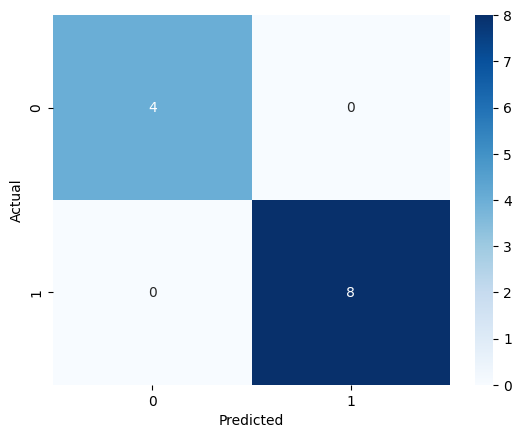

In [729]:
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [730]:
cr = classification_report(Y_test, Y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         8

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



#### **Step 13: Compare Actual vs Predicted Comparison**

In [731]:
Y_test.values

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0])

In [732]:
Y_pred.flatten()

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0])

In [733]:
df_new = pd.DataFrame({
    "Actual    Values"   :   Y_test.values                                ,
    "Predicted Values"   :   Y_pred.flatten()
})

In [734]:
df_new

,Actual Values,Predicted Values
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


#### **Step 14: Predict the output or the sample data whether the student is pass or fail**

In [735]:
### Sample data
new_students = np.array([
    [4, 65, 45],   # Weak student → likely Fail
    [7, 80, 60],   # Borderline → likely Pass
    [10, 90, 75]   # Strong student → Pass
])

print(new_students)

### Transform the sample data
transformed_data = sc.transform(new_students)
print(transformed_data)

### perform the predictions on the sample transformed data
prediction_probability = model.predict(transformed_data)
print(prediction_probability)

predictions = (prediction_probability > 0.5).astype(int)
print(predictions)

result_df = pd.DataFrame({
    "Study_Hours": new_students[:, 0],
    "Attendance": new_students[:, 1],
    "Previous_Score": new_students[:, 2],
    "Pass_Probability": prediction_probability.flatten(),
    "Predicted_Result": predictions.flatten()
})

print(result_df)

result_df["Predicted_Result"] = result_df["Predicted_Result"].map({1:"Pass", 0:"Fail"})

[[ 4 65 45]
 [ 7 80 60]
 [10 90 75]]
[[-1.02260102 -0.95778824 -0.96573003]
 [-0.2135101   0.04309352 -0.17558728]
 [ 0.59558081  0.71034803  0.61455548]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.3026351 ]
 [0.9562452 ]
 [0.99984175]]
[[0]
 [1]
 [1]]
   Study_Hours  Attendance  Previous_Score  Pass_Probability  Predicted_Result
0            4          65              45          0.302635                 0
1            7          80              60          0.956245                 1
2           10          90              75          0.999842                 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [736]:
result_df

,Study_Hours,Attendance,Previous_Score,Pass_Probability,Predicted_Result
0,4,65,45,0.302635,Fail
1,7,80,60,0.956245,Pass
2,10,90,75,0.999842,Pass
